In [11]:
import pandas as pd
import json

# --- 1️⃣ Đọc file JSON dòng ---
records = [json.loads(line) for line in open('example.txt', 'r', encoding='utf-8') if not line.startswith('{"_heartbeat_":')]
df = pd.DataFrame(records)

# --- Xem sơ bộ ---
print("🧾 Tổng số bản ghi:", len(df))
display(df.head())

# --- 2️⃣ Số lượng quốc gia và quốc gia có nhiều truy cập nhất ---
country_counts = df['c'].value_counts(dropna=False)
print("\n🌍 Top quốc gia có nhiều lượt truy cập nhất:")
display(country_counts.head(10))

# --- 3️⃣ Các bang (State) của Mỹ có nhiều lượt truy cập nhất ---
state_counts = df['gr'].value_counts()
print("\n🏛️ Top bang (State) của Mỹ có nhiều lượt truy cập nhất:")
display(state_counts.head(10))

# --- 4️⃣ Top thành phố (City) ---
city_counts = df['cy'].value_counts()
print("\n🏙️ Top thành phố có nhiều lượt truy cập nhất:")
display(city_counts.head(10))

# --- 5️⃣ Top host/domain được truy cập nhiều nhất ---
host_counts = df['hh'].value_counts()
print("\n🌐 Top domain (host) được truy cập nhiều nhất:")
display(host_counts.head(10))

# --- 6️⃣ Phân bố lượt truy cập theo múi giờ ---
tz_counts = df['tz'].value_counts()
print("\n⏰ Top múi giờ (timezone):")
display(tz_counts.head(10))

# --- 7️⃣ Tỷ lệ truy cập từ thiết bị di động vs máy tính ---
# Gợi ý đơn giản: nếu user agent chứa "iPhone", "Android", "iPad" -> mobile
df['device_type'] = df['a'].fillna('').apply(
    lambda x: 'Mobile' if any(k in x for k in ['iPhone', 'Android', 'iPad']) else 'Desktop'
)
device_counts = df['device_type'].value_counts()
print("\n📱💻 Tỷ lệ thiết bị truy cập:")
display(device_counts)


🧾 Tổng số bản ghi: 3440


,a,c,nk,tz,gr,g,h,l,al,hh,r,u,t,hc,cy,ll,kw
0,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,1,America/New_York,MA,A6qOVH,wfLQtf,orofrog,"en-US,en;q=0.8",1.usa.gov,http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/...,http://www.ncbi.nlm.nih.gov/pubmed/22415991,1331923247,1331822918,Danvers,"[42.576698, -70.954903]",NaN
1,GoogleMaps/RochesterNY,US,0,America/Denver,UT,mwszkS,mwszkS,bitly,NaN,j.mp,http://www.AwareMap.com/,http://www.monroecounty.gov/etc/911/rss.php,1331923249,1308262393,Provo,"[40.218102, -111.613297]",NaN
2,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...,US,1,America/New_York,DC,xxr3Qb,xxr3Qb,bitly,en-US,1.usa.gov,http://t.co/03elZC4Q,http://boxer.senate.gov/en/press/releases/0316...,1331923250,1331919941,Washington,"[38.9007, -77.043098]",NaN
3,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_8)...,BR,0,America/Sao_Paulo,27,zCaLwp,zUtuOu,alelex88,pt-br,1.usa.gov,direct,http://apod.nasa.gov/apod/ap120312.html,1331923249,1331923068,Braz,"[-23.549999, -46.616699]",NaN
4,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,0,America/New_York,MA,9b6kNl,9b6kNl,bitly,"en-US,en;q=0.8",bit.ly,http://www.shrewsbury-ma.gov/selco/,http://www.shrewsbury-ma.gov/egov/gallery/1341...,1331923251,1273672411,Shrewsbury,"[42.286499, -71.714699]",NaN



🌍 Top quốc gia có nhiều lượt truy cập nhất:


c
US      2305
None     521
GB        74
CA        60
ES        37
JP        37
BR        35
DE        28
IT        27
NL        22
Name: count, dtype: int64


🏛️ Top bang (State) của Mỹ có nhiều lượt truy cập nhất:


...

hh
1.usa.gov      2781
bit.ly          261
go.nasa.gov     236
j.mp             82
on.doi.gov       19
gr.pn            13
ds.io            12
bitly.com         9
aash.to           7
lat.ms            3
Name: count, dtype: int64


⏰ Top múi giờ (timezone):


tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Europe/London            74
Asia/Tokyo               37
Pacific/Honolulu         36
Europe/Madrid            35
America/Sao_Paulo        33
Name: count, dtype: int64


📱💻 Tỷ lệ thiết bị truy cập:


device_type
Desktop    2893
Mobile      547
Name: count, dtype: int64

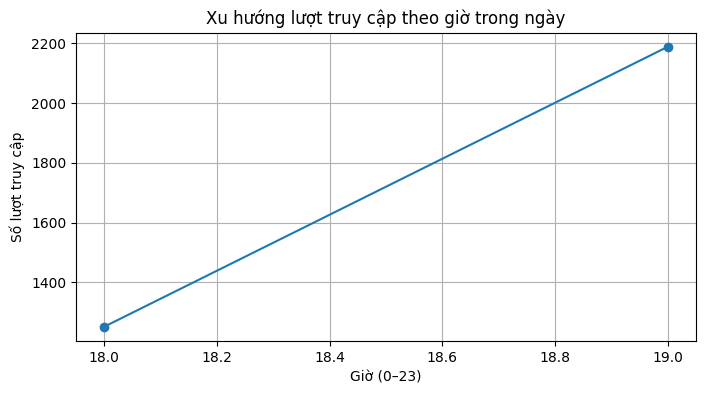

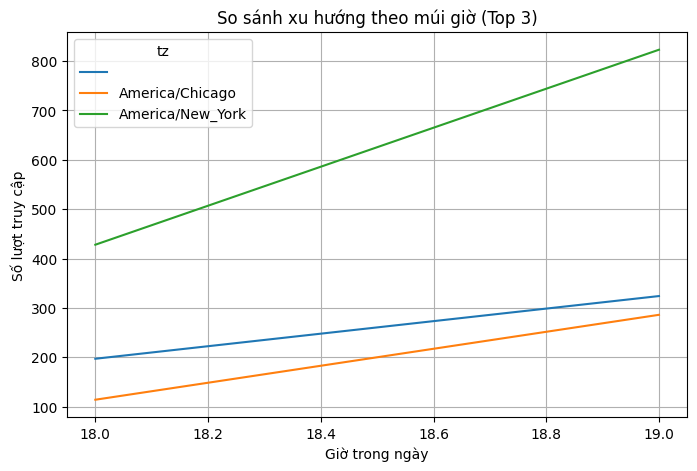

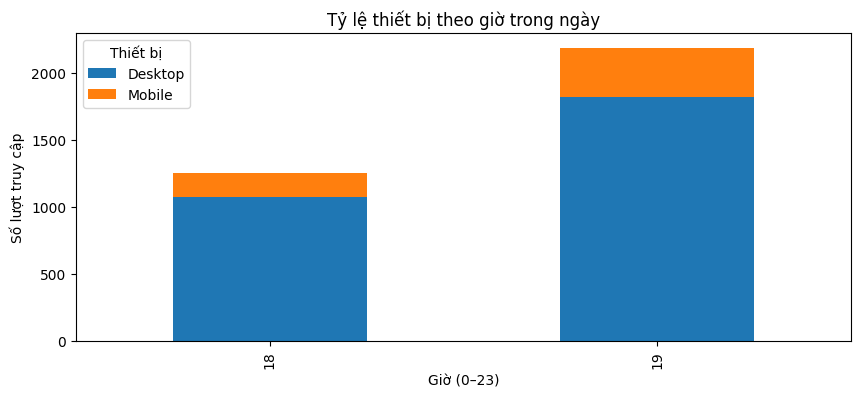

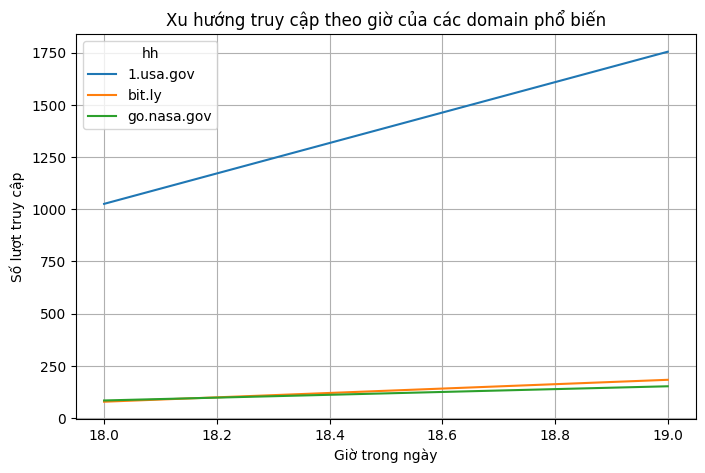

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Chuyển cột thời gian từ Unix timestamp sang dạng datetime
df['datetime'] = pd.to_datetime(df['t'], unit='s')

# 1️⃣ Xu hướng tổng lượt truy cập theo thời gian (theo giờ)
df['hour'] = df['datetime'].dt.hour
hourly = df.groupby('hour').size()

plt.figure(figsize=(8,4))
hourly.plot(kind='line', marker='o', title='Xu hướng lượt truy cập theo giờ trong ngày')
plt.xlabel('Giờ (0–23)')
plt.ylabel('Số lượt truy cập')
plt.grid(True)
plt.show()

# 2️⃣ Xu hướng theo ngày (nếu dữ liệu có nhiều ngày)
df['date'] = df['datetime'].dt.date
daily = df.groupby('date').size()
if len(daily) > 1:
    plt.figure(figsize=(8,4))
    daily.plot(kind='line', marker='o', title='Xu hướng lượt truy cập theo ngày')
    plt.xlabel('Ngày')
    plt.ylabel('Số lượt truy cập')
    plt.grid(True)
    plt.show()

# 3️⃣ So sánh giữa các múi giờ phổ biến
top_tz = df['tz'].value_counts().head(3).index
tz_hour = df[df['tz'].isin(top_tz)].groupby(['tz','hour']).size().unstack(fill_value=0)

tz_hour.T.plot(figsize=(8,5), title='So sánh xu hướng theo múi giờ (Top 3)')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượt truy cập')
plt.grid(True)
plt.show()

# 4️⃣ So sánh tỷ lệ thiết bị theo thời gian
device_hour = df.groupby(['hour','device_type']).size().unstack(fill_value=0)
device_hour.plot(kind='bar', stacked=True, figsize=(10,4), title='Tỷ lệ thiết bị theo giờ trong ngày')
plt.xlabel('Giờ (0–23)')
plt.ylabel('Số lượt truy cập')
plt.legend(title='Thiết bị')
plt.show()

# 5️⃣ Xu hướng truy cập của các domain phổ biến
top_hosts = df['hh'].value_counts().head(3).index
domain_trend = df[df['hh'].isin(top_hosts)].groupby(['hh','hour']).size().unstack(fill_value=0)

domain_trend.T.plot(figsize=(8,5), title='Xu hướng truy cập theo giờ của các domain phổ biến')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượt truy cập')
plt.grid(True)
plt.show()


Tổng lượt truy cập theo thiết bị:
device_type
Desktop    2893
Mobile      547
Name: count, dtype: int64


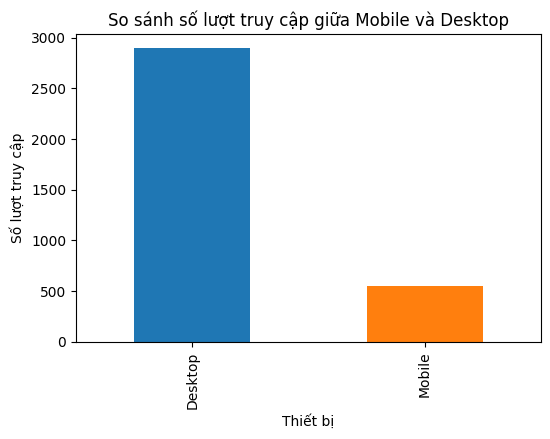

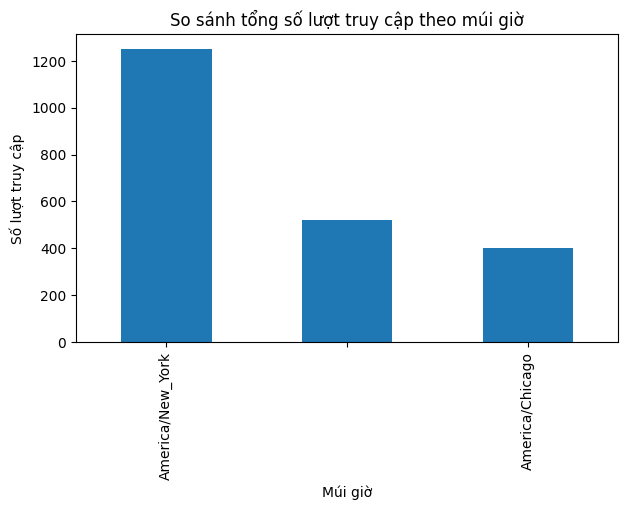

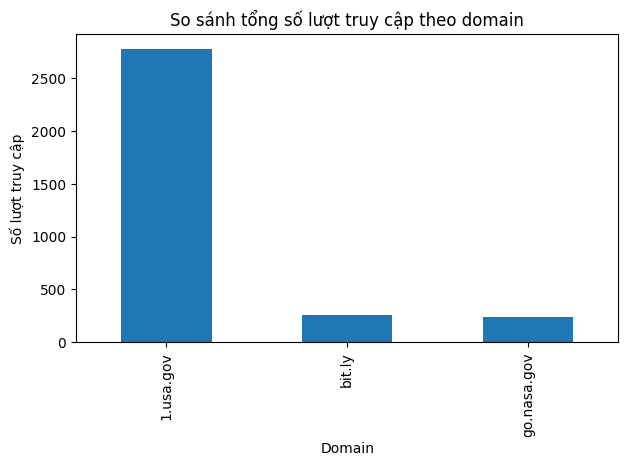

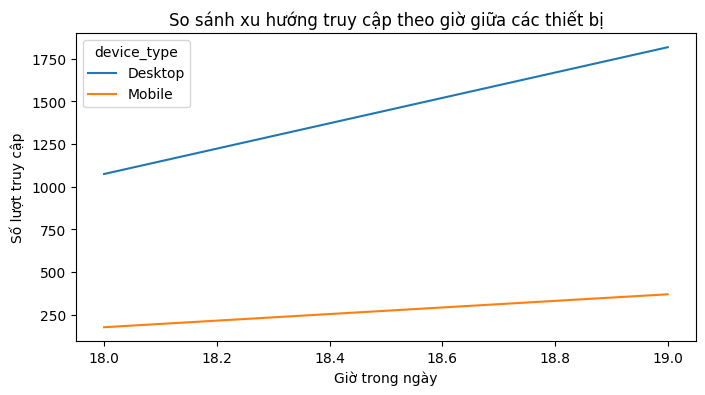

In [13]:
import matplotlib.pyplot as plt

# --- 1️⃣ So sánh lượt truy cập giữa thiết bị di động và máy tính ---
device_counts = df['device_type'].value_counts()
print("Tổng lượt truy cập theo thiết bị:")
print(device_counts)

device_counts.plot(kind='bar', color=['#1f77b4','#ff7f0e'], figsize=(6,4),
                   title='So sánh số lượt truy cập giữa Mobile và Desktop')
plt.xlabel('Thiết bị')
plt.ylabel('Số lượt truy cập')
plt.show()

# --- 2️⃣ So sánh hành vi theo múi giờ ---
top_tz = df['tz'].value_counts().head(3).index
tz_total = df[df['tz'].isin(top_tz)].groupby('tz').size().sort_values(ascending=False)

tz_total.plot(kind='bar', figsize=(7,4), title='So sánh tổng số lượt truy cập theo múi giờ')
plt.ylabel('Số lượt truy cập')
plt.xlabel('Múi giờ')
plt.show()

# --- 3️⃣ So sánh mức độ hoạt động giữa các domain phổ biến ---
top_hosts = df['hh'].value_counts().head(3).index
domain_counts = df[df['hh'].isin(top_hosts)].groupby('hh').size().sort_values(ascending=False)

domain_counts.plot(kind='bar', figsize=(7,4), title='So sánh tổng số lượt truy cập theo domain')
plt.ylabel('Số lượt truy cập')
plt.xlabel('Domain')
plt.show()

# --- 4️⃣ So sánh xu hướng theo giờ của các nhóm thiết bị ---
hourly_device = df.groupby(['hour', 'device_type']).size().unstack(fill_value=0)
hourly_device.plot(figsize=(8,4), title='So sánh xu hướng truy cập theo giờ giữa các thiết bị')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượt truy cập')
plt.show()
